In [4]:
#COntour to fda ans save in a single netcdf
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns  # Optional for aesthetics
from scipy.stats import linregress
import datetime
from concave_hull import concave_hull, concave_hull_indexes
from sklearn.cluster import DBSCAN
import numpy as np
import skfda
from scipy.linalg import pinv

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
fig_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_fig15/'
shape_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15/'

In [5]:
#Load all
file_list = glob.glob(shape_path + '*.nc')
ds = xr.open_dataset(file_list[0])
ds

<xarray.Dataset>
Dimensions:  (time: 1, C15x: 1203, C15y: 1203)
Coordinates:
  * time     (time) datetime64[ns] 2001-07-03T12:00:00
  * C15x     (C15x) float64 -2.512e+03 -2.488e+03 ... -2.462e+03 -2.488e+03
  * C15y     (C15y) float64 1.312e+03 1.288e+03 ... 1.312e+03 1.312e+03
Data variables:
    *empty*
Attributes: (12/43)
    title:                     Sea Ice Concentration Climate Data Record Vers...
    summary:                   This climate data record of sea ice concentrat...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -16.62393
    geospatial_lon_min:        -180.0
    ...                        ...
    algorithm:                 SICCI3LF (19V, 37V, 37H)
    references:                Product User Manual v3 (2022),Algorithm Theore...
    contributor_name:          Thomas Lavergne,Atle Soerensen,Rasmus Tonboe,C...
    contributor_role:          PrincipalInvestigator,author,author,author,aut...
    source:                    FCDR of SMMR / SSMI / SSMIS Brightness Tempera...
    product_status:            released

Text(0.5, 1.0, '2001-07-03')

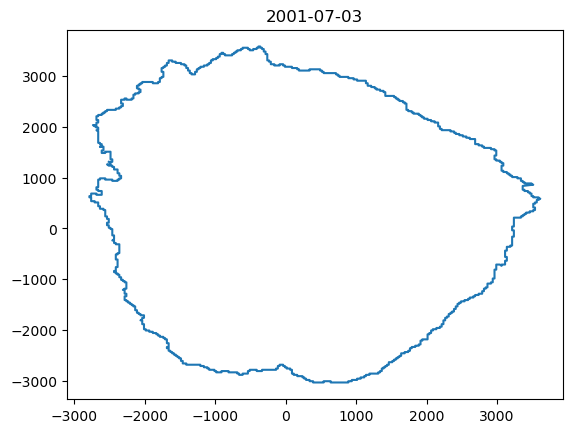

In [6]:
plt.plot(ds.C15x,ds.C15y)
plt.title(str(ds.time.data[0])[0:10])

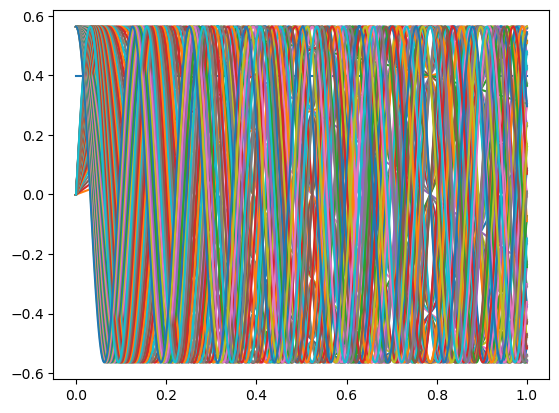

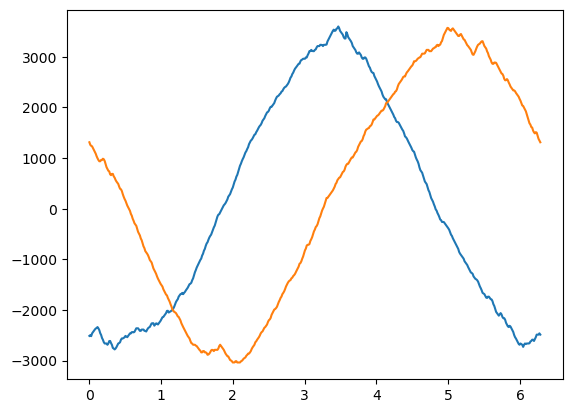

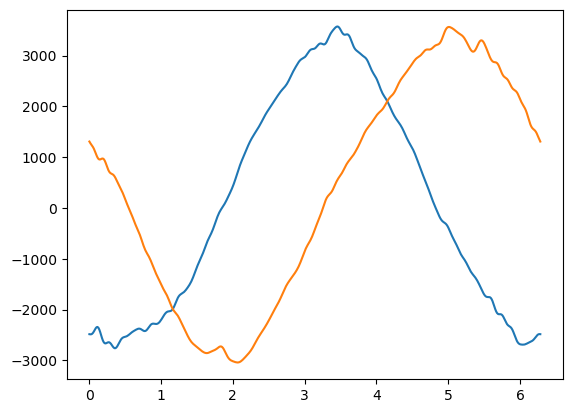

In [9]:
# Create Fourier basis
m = 100  # Number of basis functions
period = 2 * np.pi 
basis = skfda.representation.basis.Fourier(n_basis=m, period=period)
basis.plot()
plt.show()

#Data to FDataGrid
x = ds.C15x
y = ds.C15y
data_matrix = [x, y]
grid = np.linspace(0, period, len(x))
X = skfda.FDataGrid(data_matrix,grid)

#Project
X_basis = X.to_basis(basis)

X.plot()
X_basis.plot()
plt.show()

In [12]:
ls -l /Users/epauthen/opt/anaconda3/lib/python3.8/site-packages/skfda/representation/basis/

total 192
-rw-r--r--   1 epauthenet  staff    340 Jul 20  2021 __init__.py
drwxr-xr-x  12 epauthenet  staff    384 Jul 20  2021 __pycache__/
-rw-r--r--   1 epauthenet  staff  10930 Jul 20  2021 _basis.py
-rw-r--r--   1 epauthenet  staff  12484 Jul 20  2021 _bspline.py
-rw-r--r--   1 epauthenet  staff   1284 Jul 20  2021 _coefficients_transformer.py
-rw-r--r--   1 epauthenet  staff   1381 Jul 20  2021 _constant.py
-rw-r--r--   1 epauthenet  staff  31160 Jul 20  2021 _fdatabasis.py
-rw-r--r--   1 epauthenet  staff   6762 Jul 20  2021 _fourier.py
-rw-r--r--   1 epauthenet  staff   3411 Jul 20  2021 _monomial.py
-rw-r--r--   1 epauthenet  staff   3222 Jul 20  2021 _tensor_basis.py
-rw-r--r--   1 epauthenet  staff   4776 Jul 20  2021 _vector_basis.py
